# Model Evaluation & Threshold Selection — Turning Scores into Decisions

**Author:** Shivani Bokka
**Dataset:** Adult Census Income (imbalanced binary classification)
**Goal:** Measure a classifier honestly, and choose the decision threshold on purpose — not by accident

---

## What Is This Notebook About?

Here is a fact that surprises many beginners: **a classifier does not output a class. It outputs a probability.**
Something has to turn "there's a 0.63 chance this person earns >\$50K" into an actual yes/no decision. That
something is a **threshold** — and almost everyone leaves it at the default of 0.5 without a second thought.

That default is **arbitrary**, and for imbalanced or high-stakes problems it's often the *wrong* choice. This
notebook is about two tightly linked skills:

1. **Evaluating** a classifier honestly (why accuracy lies, and what to use instead).
2. **Choosing the threshold** deliberately — to hit a target recall, to maximize F1, or to minimize real
   business cost.

> **The one-sentence idea:** the model gives you a ranking; *you* decide where to draw the line — and that line
> should reflect what mistakes actually cost you.

---

## What You Will Learn

| # | Section | Key Idea |
|---|---------|----------|
| 1 | Imports and Setup | Libraries |
| 2 | Train a Model & Get Probabilities | The model outputs scores, not labels |
| 3 | Why Accuracy Lies | The imbalance trap |
| 4 | The Confusion Matrix & Its Metrics | Precision, recall, specificity, F1 |
| 5 | The ROC Curve & AUC | Ranking quality across all thresholds |
| 6 | The Precision-Recall Curve & AP | The right curve for imbalance |
| 7 | ROC vs PR — Which to Trust | And when |
| 8 | The Threshold Is a Choice | Sweeping it and watching the trade-off |
| 9 | Principled Threshold Selection | Max-F1, Youden's J, target recall |
| 10 | Cost-Sensitive Thresholds | When a miss costs more than a false alarm |
| 11 | Default vs Chosen Threshold | Seeing the decision shift |
| 12 | A Word on Calibration | Thresholds need meaningful probabilities |
| 13 | Summary | Decision guide + common mistakes |

---


## Step 1 — Imports and Setup

scikit-learn's `metrics` module has everything we need: curves (`roc_curve`, `precision_recall_curve`),
summary scores (`roc_auc_score`, `average_precision_score`), and the confusion matrix.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, roc_auc_score, precision_recall_curve, average_precision_score,
)
from lightgbm import LGBMClassifier

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
print("Libraries imported.")


Libraries imported.


## Step 2 — Train a Model & Get Probabilities

We train a LightGBM classifier on the Adult data (predict >\$50K). The key line is `predict_proba` — instead of
asking for a label, we ask for the **probability** of the positive class. Those probabilities are the raw
material for everything that follows.

Adult is **imbalanced** (~24% earn >50K), which is exactly the setting where thresholds and the right metrics
matter most.


In [2]:
adult = fetch_openml('adult', version=2, as_frame=True).frame.drop(columns=['fnlwgt', 'education'])
y = (adult['class'].astype(str) == '>50K').astype(int)
X = adult.drop(columns=['class']).copy()
for c in X.select_dtypes(exclude='number').columns:
    X[c] = X[c].astype('category').cat.codes
X, _, y, _ = train_test_split(X, y, train_size=12000, stratify=y, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

model = LGBMClassifier(n_estimators=300, learning_rate=0.05, random_state=42, verbose=-1)
model.fit(X_train, y_train)

# The crucial output: a PROBABILITY of >50K for each test person (not a 0/1 label)
y_prob = model.predict_proba(X_test)[:, 1]
print(f"Positive (>50K) rate in test set: {y_test.mean():.1%}")
print(f"First five predicted probabilities: {np.round(y_prob[:5], 3)}")
print("These are scores between 0 and 1 — we still have to choose where to cut them into yes/no.")


Positive (>50K) rate in test set: 23.9%
First five predicted probabilities: [0.009 0.014 0.466 0.134 0.   ]
These are scores between 0 and 1 — we still have to choose where to cut them into yes/no.


## Step 3 — Why Accuracy Lies

The most common beginner mistake is judging an imbalanced classifier by **accuracy**. Watch what happens when
we compare our model to a "model" that does nothing but predict the majority class every time.


In [3]:
y_pred_default = (y_prob >= 0.5).astype(int)     # the usual 0.5 threshold
model_acc = accuracy_score(y_test, y_pred_default)

# The "dummy" that always predicts the majority class (<=50K)
dummy_acc = accuracy_score(y_test, np.zeros_like(y_test))

print(f"Our LightGBM accuracy (threshold 0.5): {model_acc:.4f}")
print(f"'Always predict <=50K' accuracy:       {dummy_acc:.4f}")
print(f"\nThe do-nothing baseline already scores {dummy_acc:.1%} — just by ignoring the minority class entirely.")
print("Accuracy barely separates a real model from a useless one on imbalanced data. We need better metrics.")


Our LightGBM accuracy (threshold 0.5): 0.8590
'Always predict <=50K' accuracy:       0.7607

The do-nothing baseline already scores 76.1% — just by ignoring the minority class entirely.
Accuracy barely separates a real model from a useless one on imbalanced data. We need better metrics.


### Why this happens

Because ~76% of people earn ≤50K, a lazy "always ≤50K" rule is right 76% of the time — while catching **zero**
high earners. Accuracy rewards this uselessness. The fix is to measure performance **on the class we care
about**, which brings us to the confusion matrix and its metrics.


## Step 4 — The Confusion Matrix & Its Metrics

The **confusion matrix** is the foundation of all classification metrics. It cross-tabulates what actually
happened against what the model predicted, giving four numbers:

- **TP** (true positive): actually >50K, predicted >50K ✓
- **TN** (true negative): actually ≤50K, predicted ≤50K ✓
- **FP** (false positive): actually ≤50K, predicted >50K ✗ (a *false alarm*)
- **FN** (false negative): actually >50K, predicted ≤50K ✗ (a *miss*)

From these come the metrics that actually matter:

| Metric | Formula | Plain English |
|--------|---------|---------------|
| **Precision** | TP / (TP + FP) | Of those we *flagged* as >50K, how many really were? (few false alarms) |
| **Recall** (sensitivity) | TP / (TP + FN) | Of all the *actual* >50K people, how many did we catch? (few misses) |
| **Specificity** | TN / (TN + FP) | Of all the actual ≤50K people, how many did we correctly leave alone? |
| **F1** | harmonic mean of P & R | A single number balancing precision and recall |


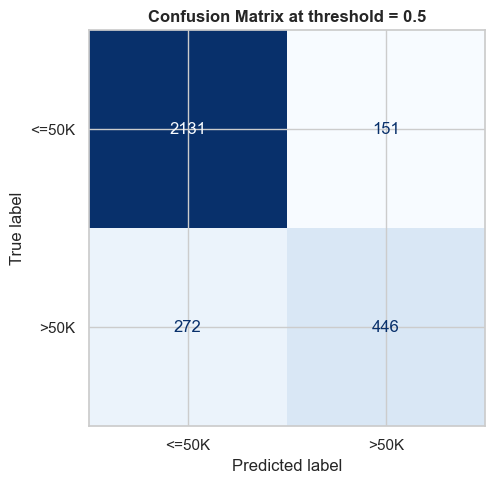

TP=446  TN=2131  FP=151  FN=272
Precision  = TP/(TP+FP) = 0.747
Recall     = TP/(TP+FN) = 0.621
Specificity= TN/(TN+FP) = 0.934
F1         = 0.678


In [4]:
cm = confusion_matrix(y_test, y_pred_default)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=['<=50K', '>50K']).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix at threshold = 0.5', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"TP={tp}  TN={tn}  FP={fp}  FN={fn}")
print(f"Precision  = TP/(TP+FP) = {tp/(tp+fp):.3f}")
print(f"Recall     = TP/(TP+FN) = {tp/(tp+fn):.3f}")
print(f"Specificity= TN/(TN+FP) = {tn/(tn+fp):.3f}")
print(f"F1         = {f1_score(y_test, y_pred_default):.3f}")


### How to Read This Chart: Confusion Matrix

- **Rows = the truth, columns = the prediction.** The **diagonal** (top-left, bottom-right) is correct; the
  **off-diagonal** cells are the two kinds of error.
- **Top-right (FP)** = false alarms; **bottom-left (FN)** = misses. These two are what you trade off when you
  move the threshold.
- **The whole point:** precision and recall come straight from these four cells. Notice at 0.5 the model tends
  to have **more misses (FN) than false alarms** on imbalanced data — it's cautious about the rare class.

> **Precision vs recall is a see-saw.** Lower the threshold and you catch more true positives (recall up) but
> raise false alarms (precision down). There is no free lunch — only a choice, which Step 8 makes explicit.


## Step 5 — The ROC Curve & AUC

A single confusion matrix only describes **one** threshold. The **ROC curve** describes the model at **every**
threshold at once. It plots:

- **X-axis:** False Positive Rate = FP / (FP + TN) — how often we cry wolf.
- **Y-axis:** True Positive Rate = Recall = TP / (TP + FN) — how often we catch the real thing.

As we slide the threshold from 1 down to 0, we trace out the curve. **AUC** (Area Under the Curve) squeezes the
whole curve into one number: the probability that the model ranks a random positive above a random negative.
0.5 = coin flip, 1.0 = perfect.


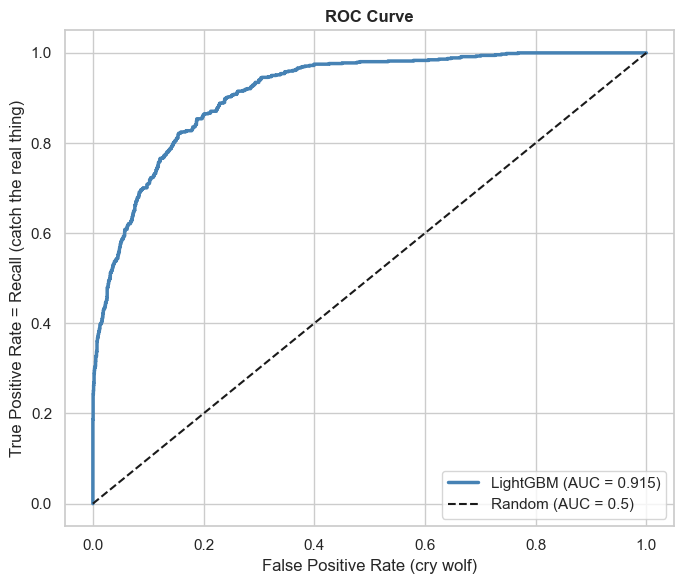

In [5]:
fpr, tpr, roc_thresh = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='steelblue', linewidth=2.5, label=f'LightGBM (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.5)')
plt.xlabel('False Positive Rate (cry wolf)')
plt.ylabel('True Positive Rate = Recall (catch the real thing)')
plt.title('ROC Curve', fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


### How to Read This Chart: ROC Curve

- **Each point** on the curve is one threshold. The **top-left corner** is the dream: catch everything (TPR=1)
  with no false alarms (FPR=0).
- **The diagonal dashed line** is a coin-flip model. **The further your curve bows toward the top-left, the
  better.** AUC measures exactly that bulge.
- **Sliding along the curve = changing the threshold.** Low threshold → top-right (catch everything, many false
  alarms). High threshold → bottom-left (few alarms, many misses).

> **AUC is threshold-free**, which makes it great for *comparing models*. But it can look flatteringly high on
> imbalanced data, because a huge number of easy true negatives inflates it — which is why we also look at the
> precision-recall curve next.


## Step 6 — The Precision-Recall Curve & Average Precision

On imbalanced data, the **precision-recall (PR) curve** is usually more honest than ROC. It plots:

- **X-axis:** Recall (of the real positives, how many did we catch?)
- **Y-axis:** Precision (of what we flagged, how many were right?)

**Average Precision (AP)** is its one-number summary (area under the PR curve). Crucially, the "no-skill"
baseline for PR is **the positive rate itself** (here ~0.24), not 0.5 — so improvements over that baseline are
meaningful.


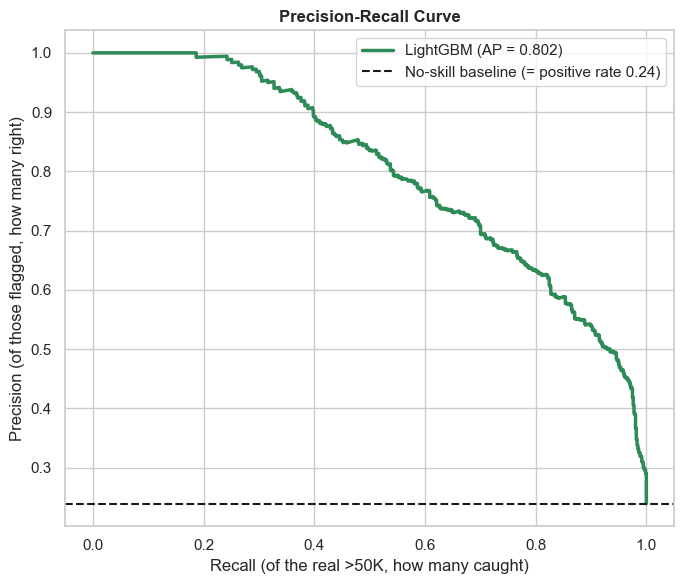

In [6]:
prec, rec, pr_thresh = precision_recall_curve(y_test, y_prob)
ap = average_precision_score(y_test, y_prob)
baseline = y_test.mean()

plt.figure(figsize=(7, 6))
plt.plot(rec, prec, color='seagreen', linewidth=2.5, label=f'LightGBM (AP = {ap:.3f})')
plt.axhline(baseline, color='k', ls='--', label=f'No-skill baseline (= positive rate {baseline:.2f})')
plt.xlabel('Recall (of the real >50K, how many caught)')
plt.ylabel('Precision (of those flagged, how many right)')
plt.title('Precision-Recall Curve', fontweight='bold')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()


### How to Read This Chart: Precision-Recall Curve

- **Top-right is the dream:** high recall *and* high precision at the same time. Real curves slope down — pushing
  recall up (right) usually costs precision (down).
- **The dashed line** is the no-skill baseline (a model guessing at the base rate). **Your curve should sit well
  above it.** The gap is your model's real value on the rare class.
- **Where to operate:** unlike ROC, this curve directly shows the precision you'd get for any target recall —
  making it the natural tool for picking a threshold on imbalanced problems.

> **Rule of thumb:** if the positive class is rare and it's the one you care about (fraud, disease, >50K here),
> **trust the PR curve over ROC.**


## Step 7 — ROC vs PR: Which to Trust?

| | **ROC / AUC** | **Precision-Recall / AP** |
|---|---------------|---------------------------|
| Axes | FPR vs TPR | Recall vs Precision |
| No-skill baseline | 0.5 (fixed diagonal) | the positive rate (moves with imbalance) |
| Best for | Balanced data; comparing models overall | **Imbalanced data; the rare positive class** |
| Weakness | Over-optimistic under heavy imbalance | Depends on the positive rate, so harder to compare across datasets |

> **Practical guidance:** report **both**, but when the positive class is rare and important, let the
> **precision-recall** curve drive your threshold decision. That's the case here.


## Step 8 — The Threshold Is a Choice

Now the heart of the notebook. The 0.5 default is just one point on the curves above. Let's **sweep the
threshold** across its whole range and watch precision, recall, and F1 move. This single chart is the one to
internalize.


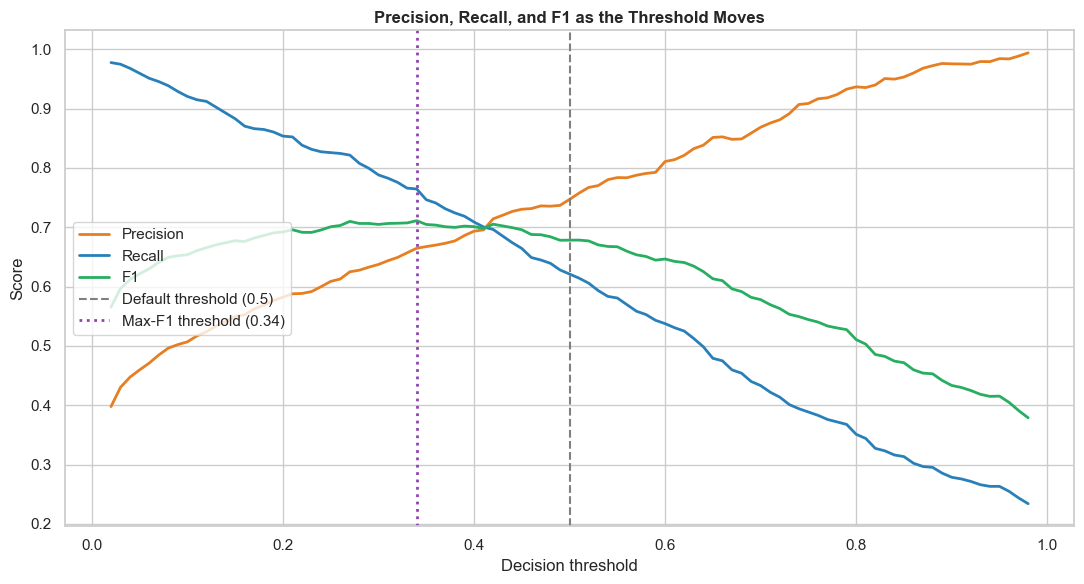

In [7]:
thresholds = np.linspace(0.02, 0.98, 97)
precisions, recalls, f1s = [], [], []
for t in thresholds:
    pred = (y_prob >= t).astype(int)
    precisions.append(precision_score(y_test, pred, zero_division=0))
    recalls.append(recall_score(y_test, pred, zero_division=0))
    f1s.append(f1_score(y_test, pred, zero_division=0))

best_f1_idx = int(np.argmax(f1s))
best_f1_t = thresholds[best_f1_idx]

plt.figure(figsize=(11, 6))
plt.plot(thresholds, precisions, label='Precision', color='#e67e22', linewidth=2)
plt.plot(thresholds, recalls, label='Recall', color='#2980b9', linewidth=2)
plt.plot(thresholds, f1s, label='F1', color='#27ae60', linewidth=2)
plt.axvline(0.5, color='gray', ls='--', label='Default threshold (0.5)')
plt.axvline(best_f1_t, color='#8e44ad', ls=':', linewidth=2, label=f'Max-F1 threshold ({best_f1_t:.2f})')
plt.xlabel('Decision threshold')
plt.ylabel('Score')
plt.title('Precision, Recall, and F1 as the Threshold Moves', fontweight='bold')
plt.legend(loc='center left')
plt.tight_layout()
plt.show()


### How to Read This Chart: The Threshold Trade-off

- **X-axis** = the cutoff we apply to the probability. **Left = permissive** (flag almost everyone as >50K),
  **right = strict** (flag almost no one).
- **Recall (blue)** always **falls** as the threshold rises — a stricter cutoff catches fewer true positives.
- **Precision (orange)** generally **rises** as the threshold rises — being strict means the ones you *do* flag
  are more likely right.
- **F1 (green)** peaks somewhere in the middle — the best *balance* of the two. The purple dotted line marks it.
- **The gray line at 0.5** is the arbitrary default. Notice it's usually **not** where F1 peaks — proof that the
  default is rarely optimal.

> **This is the master picture:** choosing a threshold means choosing a point on these curves. *Which* point
> depends on your goal — the next two steps make that goal explicit.


## Step 9 — Principled Ways to Pick a Threshold

You don't guess the threshold — you pick it to satisfy a stated goal. Three common rules:

1. **Maximize F1** — best balance of precision and recall when both matter equally.
2. **Youden's J (from ROC)** — the threshold that maximizes `TPR − FPR`; a balanced choice from the ROC side.
3. **Hit a target recall** — e.g. "we must catch at least 80% of high earners," then take the best precision
   available at that recall. Common when misses are unacceptable.


In [8]:
# 1) Max-F1 (computed in Step 8)
print(f"Max-F1 threshold:        {best_f1_t:.3f}  -> F1={f1s[best_f1_idx]:.3f}")

# 2) Youden's J = TPR - FPR, maximized over the ROC thresholds
youden_idx = int(np.argmax(tpr - fpr))
youden_t = roc_thresh[youden_idx]
print(f"Youden's J threshold:    {youden_t:.3f}  -> TPR={tpr[youden_idx]:.3f}, FPR={fpr[youden_idx]:.3f}")

# 3) Smallest threshold that still achieves at least 80% recall (then read its precision)
target_recall = 0.80
ok = [(t, precision_score(y_test, (y_prob >= t).astype(int), zero_division=0))
      for t in thresholds if recall_score(y_test, (y_prob >= t).astype(int), zero_division=0) >= target_recall]
recall_t, recall_prec = max(ok, key=lambda z: z[0])   # highest threshold that still hits the recall floor
print(f"Target-recall>=80% threshold: {recall_t:.3f}  -> precision at that point = {recall_prec:.3f}")

print("\nThree goals, three different thresholds. There is no single 'correct' one — only the right one for YOUR goal.")


Max-F1 threshold:        0.340  -> F1=0.711
Youden's J threshold:    0.270  -> TPR=0.822, FPR=0.155


Target-recall>=80% threshold: 0.280  -> precision at that point = 0.628

Three goals, three different thresholds. There is no single 'correct' one — only the right one for YOUR goal.


## Step 10 — Cost-Sensitive Thresholds (the most business-relevant)

In the real world, the two errors rarely cost the same. Missing a fraudulent transaction costs far more than
one false alarm; missing a cancer diagnosis costs far more than an extra test. The right threshold is the one
that **minimizes total expected cost**.

We'll make it concrete: suppose (for illustration) that in our application a **false negative costs 5 units**
and a **false positive costs 1 unit**. We compute total cost at every threshold and pick the cheapest.

> **Change the two costs and the optimal threshold moves.** That's the whole point — the "best" threshold is a
> business decision encoded as numbers, not a statistical constant.


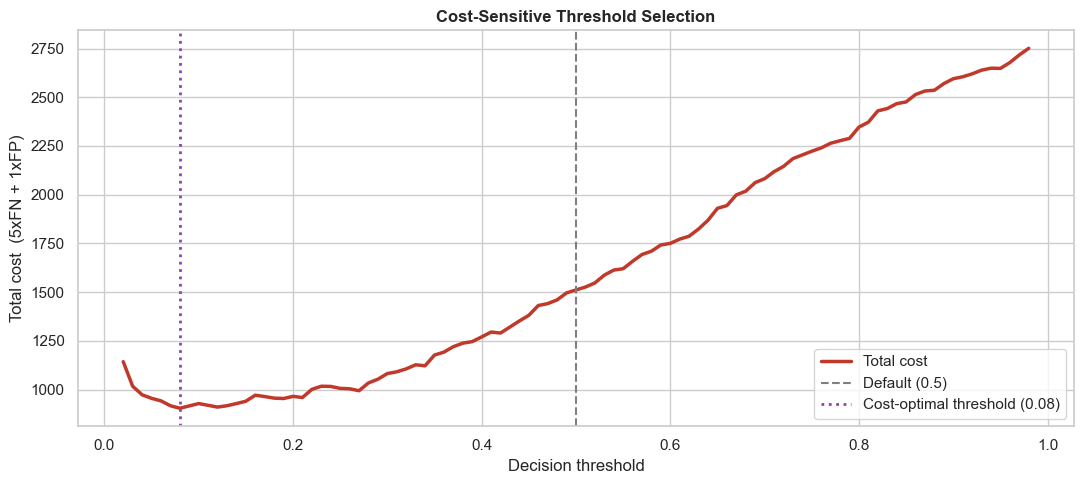

Cost at default 0.5:        1511 units
Cost at optimal 0.08:      904 units
Savings from moving the threshold: 607 units (40% lower).


In [9]:
COST_FN = 5.0   # cost of missing a true >50K  (a 'miss')
COST_FP = 1.0   # cost of a false alarm

costs = []
for t in thresholds:
    pred = (y_prob >= t).astype(int)
    tn_, fp_, fn_, tp_ = confusion_matrix(y_test, pred).ravel()
    costs.append(COST_FN * fn_ + COST_FP * fp_)

best_cost_idx = int(np.argmin(costs))
best_cost_t = thresholds[best_cost_idx]

plt.figure(figsize=(11, 5))
plt.plot(thresholds, costs, color='#c0392b', linewidth=2.5, label='Total cost')
plt.axvline(0.5, color='gray', ls='--', label='Default (0.5)')
plt.axvline(best_cost_t, color='#8e44ad', ls=':', linewidth=2,
            label=f'Cost-optimal threshold ({best_cost_t:.2f})')
plt.xlabel('Decision threshold')
plt.ylabel(f'Total cost  ({COST_FN:.0f}xFN + {COST_FP:.0f}xFP)')
plt.title('Cost-Sensitive Threshold Selection', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

cost_at_default = costs[int(np.argmin(np.abs(thresholds - 0.5)))]
print(f"Cost at default 0.5:        {cost_at_default:.0f} units")
print(f"Cost at optimal {best_cost_t:.2f}:      {costs[best_cost_idx]:.0f} units")
print(f"Savings from moving the threshold: {cost_at_default - costs[best_cost_idx]:.0f} units "
      f"({(cost_at_default - costs[best_cost_idx]) / cost_at_default:.0%} lower).")


### How to Read This Chart: Cost Curve

- **X-axis** = threshold; **Y-axis** = total cost = (5 × misses) + (1 × false alarms).
- **The curve is U-shaped:** too permissive (left) racks up false alarms; too strict (right) racks up expensive
  misses. **The bottom of the U is the cheapest place to operate.**
- **Because misses cost 5× more here, the optimal threshold sits *below* 0.5** — we deliberately accept more
  false alarms to avoid the pricier misses.
- **The gap between the gray line and the purple line** is money left on the table by blindly using 0.5.

> **This is how thresholds are set in industry:** encode the real costs, then read the minimum off this curve.


## Step 11 — Default vs Chosen Threshold: Seeing the Decision Shift

Let's make the consequence tangible: the same model, the same test set, but two different thresholds — the
default 0.5 versus our cost-optimal one. Watch the confusion matrix shift.


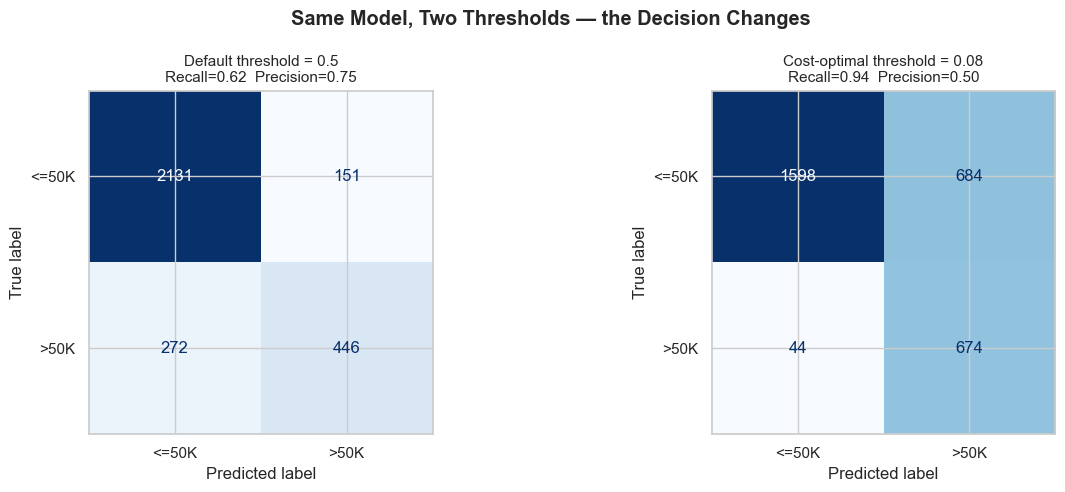

Lowering the threshold moves people from the 'miss' cell (FN) into the 'caught' cell (TP):
recall goes up, precision goes down — exactly the trade-off we chose on purpose.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, t, title in [(axes[0], 0.5, 'Default threshold = 0.5'),
                     (axes[1], best_cost_t, f'Cost-optimal threshold = {best_cost_t:.2f}')]:
    pred = (y_prob >= t).astype(int)
    cm_t = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm_t, display_labels=['<=50K', '>50K']).plot(ax=ax, colorbar=False, cmap='Blues')
    r = recall_score(y_test, pred); p = precision_score(y_test, pred)
    ax.set_title(f'{title}\nRecall={r:.2f}  Precision={p:.2f}', fontsize=11)
plt.suptitle('Same Model, Two Thresholds — the Decision Changes', fontweight='bold')
plt.tight_layout()
plt.show()
print("Lowering the threshold moves people from the 'miss' cell (FN) into the 'caught' cell (TP):")
print("recall goes up, precision goes down — exactly the trade-off we chose on purpose.")


### How to Read This Chart: The Decision Shift

- **Left = default 0.5, right = cost-optimal.** Compare the **bottom row** (the actual >50K people): the
  cost-optimal threshold moves many of them out of the **bottom-left "miss" cell** into the **bottom-right
  "caught" cell** — recall jumps.
- **The price:** the **top-right "false alarm" cell** grows — precision drops. We accepted that on purpose,
  because here a miss costs 5× a false alarm.
- **Nothing about the model changed.** Only the line we drew through its probabilities did. That's the power (and
  responsibility) of threshold selection.


## Step 12 — A Word on Calibration

Choosing a threshold like "flag everyone above 0.30" only makes sense if the model's **0.30 really means a 30%
chance**. If the model is **overconfident** (as boosted trees often are), its probabilities are distorted and
your carefully chosen threshold won't behave as expected.

The fix is **probability calibration** (Platt/sigmoid or isotonic), covered in detail in the **Boosting
notebook (02)**. The workflow in practice is: **calibrate first, then choose the threshold** on the calibrated
probabilities.

> **Rule:** thresholds are only as trustworthy as the probabilities underneath them. Calibrate before you cut.


## Step 13 — Summary and Key Takeaways

### The mental model

> A classifier gives you a **ranking** (probabilities). **Metrics** tell you how good that ranking is; the
> **threshold** turns it into decisions. Evaluate with the right metric, then set the threshold on purpose.

### Metric cheat-sheet

| Situation | Use |
|-----------|-----|
| Quick sanity check on **balanced** data | Accuracy is fine |
| **Imbalanced** data | Precision, Recall, F1 — and the **PR curve** |
| Comparing models overall, threshold-free | **AUC** (ROC) |
| Rare, important positive class | **Average Precision** (PR curve) |
| Real-world deployment with unequal error costs | **Total cost** curve → cost-optimal threshold |

### Choosing a threshold — the decision guide

```
What do you care about most?
│
├─ Balance precision & recall           → maximize F1
├─ A balanced ROC-based cut             → Youden's J (max TPR - FPR)
├─ "Never miss more than X%"            → target-recall threshold
└─ Real costs differ (miss vs alarm)    → minimize total cost  ← usually the real answer
```

### Common mistakes to avoid
1. **Judging imbalanced models by accuracy** — the do-nothing baseline already looks "good" (Step 3).
2. **Leaving the threshold at 0.5** — it's arbitrary and rarely optimal (Step 8).
3. **Using ROC/AUC alone on rare-positive problems** — pair it with the PR curve (Step 7).
4. **Setting a threshold on uncalibrated probabilities** — calibrate first (Step 12).
5. **Choosing the threshold on the test set and also reporting on it** — pick the threshold on a validation
   split, then report final numbers on the untouched test set.

### The series so far
You can now build tree, boosting, ensemble, k-NN and SVM models; tune them; explain them; and turn them into
cost-aware decisions. That is the full lifecycle of a supervised-learning model — from first split to final
deployment decision.

---

*Notebook by Shivani Bokka — Dive Deeper into Supervised Learning Series*
